<a href="https://colab.research.google.com/github/mohammed786-sk/pythonproject/blob/main/python%26machinelearnig.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("loan.csv")

print("First 5 Rows:")
print(df.head())
print("Columns in Dataset : ", df.columns)
print("Shape: ", df.shape)

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].median())

print("\n Missing values After Cleaning:")
print(df.isnull().sum())

df.drop("Loan_ID", axis=1, inplace=True)
le = LabelEncoder()
categorical_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area", "Loan_Status"]


df['Dependents'] = df['Dependents'].astype(str)

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n Accuracy Score:", accuracy_score(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\n=== Loan prediction for new Applicants ===\n")

try:
    gender = int(input("Gender (Male=1, Female=0):"))
    married = int(input("Married (Yes=1, No=0):"))
    dependents = int(input("Dependents (0-3):"))
    education = int(input("Education (Graduate=1, Not=0):"))
    self_employed = int(input("Self Employed (Yes=1, No=0):"))
    applicant_income = float(input("Applicant Income:"))
    coapplicant_income = float(input("Coapplicant Income:"))
    loan_amount = float(input("Loan Amount:"))
    loan_term = float(input("Loan Amount Term (months):"))
    credit_history = int(input("Credit History (1=Good, 0=Bad):"))
    property_area = int(input("Property Area (Rural=0, Semiurban=1, Urban=2):"))

    new_data = [[gender, married, dependents, education, self_employed, applicant_income, coapplicant_income, loan_amount, loan_term, credit_history, property_area]]

    prediction = model.predict(new_data)
    print("\n Loan Approved!" if prediction[0] == 1 else "\n Loan Rejected")
except ValueError:
    print("Invalid input, please enter numbers as instructed.")

First 5 Rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2     

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 Accuracy Score: 0.7886178861788617

 Confusion Matrix:
 [[18 25]
 [ 1 79]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


=== Loan prediction for new Applicants ===

Gender (Male=1, Female=0):1
Married (Yes=1, No=0):0
Dependents (0-3):1
Education (Graduate=1, Not=0):2
Self Employed (Yes=1, No=0):1
Applicant Income:2
Coapplicant Income:1
Loan Amount:2
Loan Amount Term (months):1
Credit History (1=Good, 0=Bad):2
Property Area (Rural=0, Semiurban=1, Urban=2):1

 Loan Approved!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


None

### Handling Missing Values
We will fill missing values in categorical columns with the mode and numerical columns with the median.

In [ ]:
display(df.describe())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.817590,0.653094,0.744300,0.218241,0.133550,5403.459283,1621.245798,145.752443,342.410423,0.855049,1.037459,0.687296
std,0.386497,0.476373,1.009623,0.413389,0.340446,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.787482,0.463973
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,2.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,2.000000,1.000000


In [ ]:
display(df.describe())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.817590,0.653094,0.744300,0.218241,0.133550,5403.459283,1621.245798,145.752443,342.410423,0.855049,1.037459,0.687296
std,0.386497,0.476373,1.009623,0.413389,0.340446,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.787482,0.463973
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,2.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,2.000000,1.000000


In [ ]:
display(df.isnull().sum)

<bound method DataFrame.sum of      Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0     False    False       False      False          False            False   
1     False    False       False      False          False            False   
2     False    False       False      False          False            False   
3     False    False       False      False          False            False   
4     False    False       False      False          False            False   
..      ...      ...         ...        ...            ...              ...   
609   False    False       False      False          False            False   
610   False    False       False      False          False            False   
611   False    False       False      False          False            False   
612   False    False       False      False          False            False   
613   False    False       False      False          False            False   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                False       False             False           False   
1                False       False             False           False   
2                False       False             False           False   
3                False       False             False           False   
4                False       False             False           False   
..                 ...         ...               ...             ...   
609              False       False             False           False   
610              False       False             False           False   
611              False       False             False           False   
612              False       False             False           False   
613              False       False             False           False   

     Property_Area  Loan_Status  
0            False        False  
1            False        False  
2            False        False  
3            False        False  
4            False        False  
..             ...          ...  
609          False        False  
610          False        False  
611          False        False  
612          False        False  
613          False        False  

[614 rows x 12 columns]>

In [ ]:
display(df)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [ ]:
df.dropna(inplace=True)

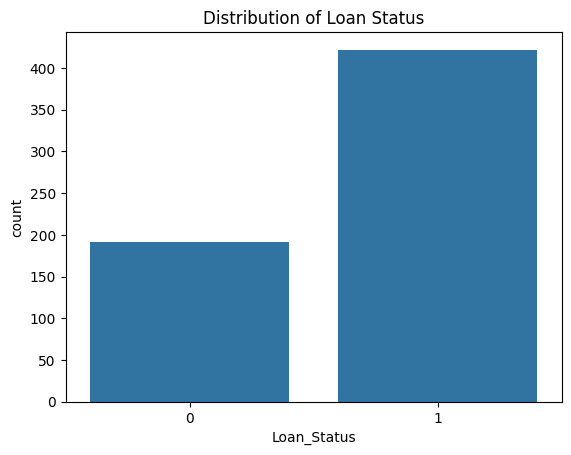

In [ ]:
sns.countplot(x='Loan_Status', data=df)
plt.title('Distribution of Loan Status')
plt.show()

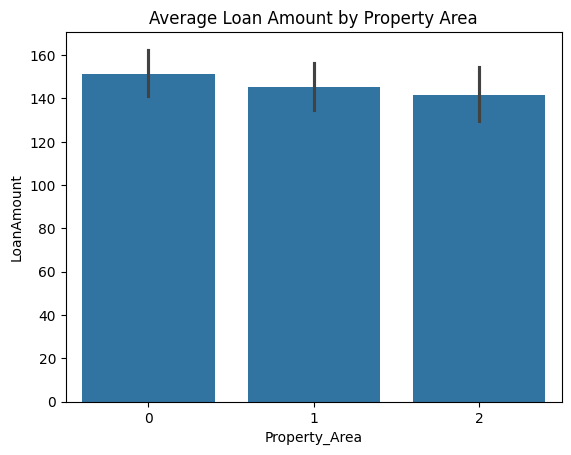

In [ ]:
sns.barplot(x='Property_Area',y='LoanAmount',data=df)
plt.title("Average Loan Amount by Property Area")
plt.show()

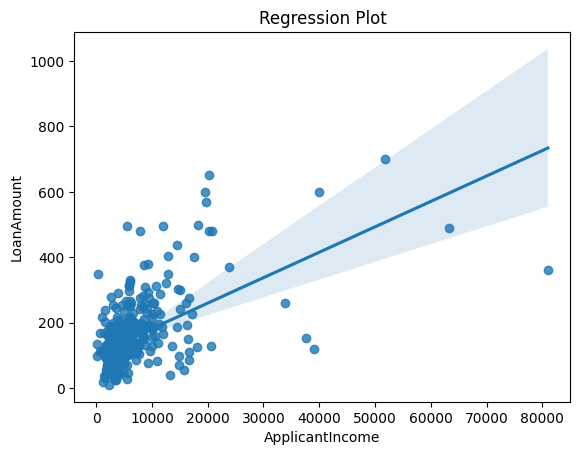

In [ ]:
sns.regplot(x='ApplicantIncome',y='LoanAmount',data=df)
plt.title("Regression Plot")
plt.show()

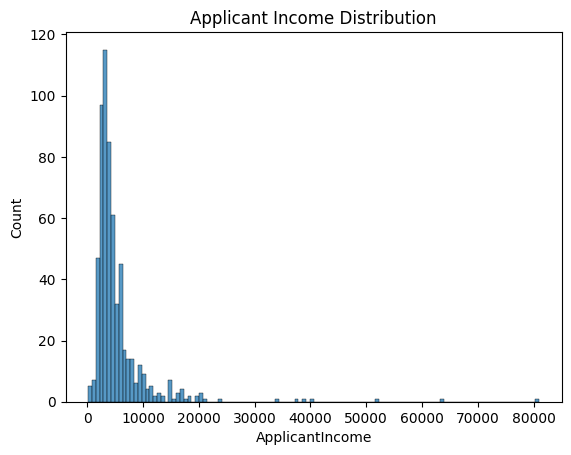

In [ ]:
sns.histplot(df['ApplicantIncome'])
plt.title("Applicant Income Distribution")
plt.show()

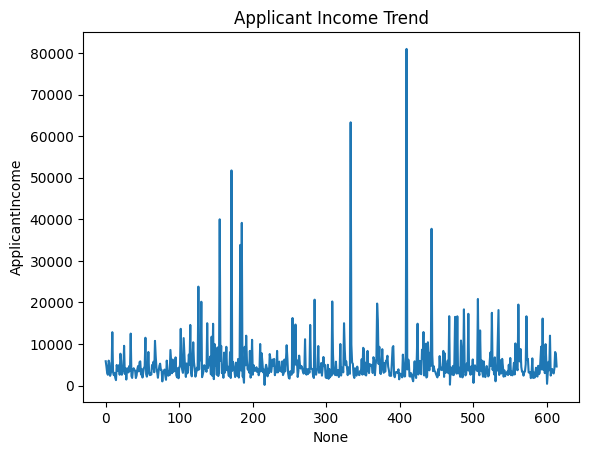

In [ ]:
sns.lineplot(x=df.index,y='ApplicantIncome',data=df)
plt.title("Applicant Income Trend")
plt.show()

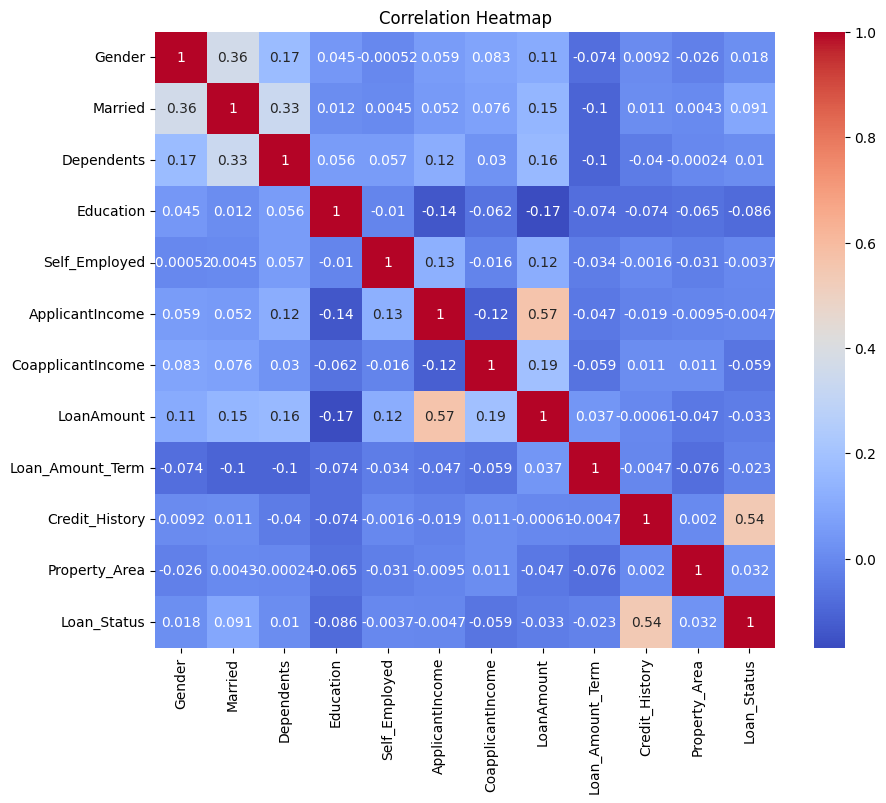

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

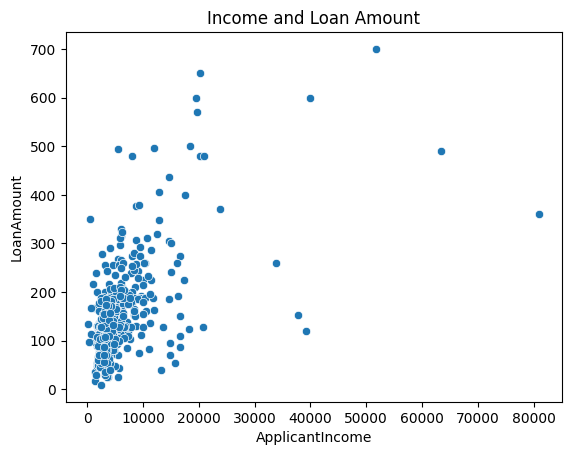

In [ ]:
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.title("Income and Loan Amount")
plt.show()

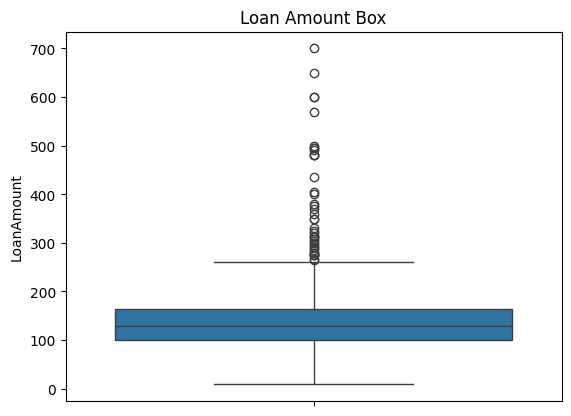

In [ ]:
sns.boxplot(y='LoanAmount', data=df)
plt.title("Loan Amount Box")
plt.show()

SyntaxError: invalid syntax (3277417328.py, line 1)